In [5]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(f"PyTorch version: {torch.__version__}")

cpu
PyTorch version: 2.5.1


In [6]:
import joblib

X_train_seq = joblib.load("X_train_seq.pkl")
y_train_seq = joblib.load("y_train_seq.pkl")
X_val_seq = joblib.load("X_val_seq.pkl")
y_val_seq = joblib.load("y_val_seq.pkl")
X_test_seq = joblib.load("X_test_seq.pkl")
print("Data loaded successfully.")
print({k: v.shape for k, v in X_train_seq.items()})
print(f"y_train_seq shape: {y_train_seq.shape}")
print({k: v.shape for k, v in X_val_seq.items()})
print(f"y_val_seq shape: {y_val_seq.shape}")

Data loaded successfully.
{'cont': torch.Size([5346, 32, 30]), 'survey': torch.Size([5346, 32, 4]), 'body': torch.Size([5346, 32, 1]), 'time': torch.Size([5346, 32, 1])}
y_train_seq shape: torch.Size([5346])
{'cont': torch.Size([603, 32, 30]), 'survey': torch.Size([603, 32, 4]), 'body': torch.Size([603, 32, 1]), 'time': torch.Size([603, 32, 1])}
y_val_seq shape: torch.Size([603])


In [7]:
from classes import Dataset

train_ds = Dataset(X_train_seq['cont'], X_train_seq['survey'], X_train_seq['body'], y_train_seq,  X_train_seq['time'],)
val_ds   = Dataset(X_val_seq['cont'], X_val_seq['survey'], X_val_seq['body'], y_val_seq, X_val_seq['time'])

In [8]:
from sklearn.utils.class_weight import compute_class_weight
from torch import nn

# Hyperparameters

BATCH_SIZE = 128

# Training configuration
LEARNING_RATE = 5e-4
EPOCHS = 500
PATIENCE = 50

# Architecture
HIDDEN_LAYERS = 2       
HIDDEN_SIZE = 64      

# Regularization
DROPOUT_RATE = 0.45    
L1_LAMBDA = 0       
L2_LAMBDA = 2e-4       



counts = np.bincount(y_train_seq)  # [n0, n1, n2]
beta = 0.999
cb = (1 - beta) / (1 - beta**counts)
cb = cb / cb.sum()


boost = torch.tensor([1.00, 1.00, 1.2], device=device, dtype=torch.float32)
weights = torch.tensor(cb, device=device, dtype=torch.float32) * boost
weights = weights / weights.sum()
print(weights)

criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)

tensor([0.1640, 0.3017, 0.5342])


In [9]:
from utils import make_loader


# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, balanced_sampling=True)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)



# Get one batch from the training data loader
for (cont, survey, body, time), yb in train_loader:
    print("Continuous features:", cont.shape)
    print("Survey features:", survey.shape)
    print("Body features:", body.shape)
    print("Time features:", body.shape)
    print("Labels:", yb.shape)
    break

Continuous features: torch.Size([128, 32, 30])
Survey features: torch.Size([128, 32, 4])
Body features: torch.Size([128, 32, 1])
Time features: torch.Size([128, 32, 1])
Labels: torch.Size([128])


In [10]:
inputs, label = train_ds[0]
print("Label:", label, label.shape if hasattr(label, "shape") else None)


Label: tensor(0) torch.Size([])


In [11]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [12]:
from classes import Transformer

transformer_model = Transformer(
    n_cont=30,
    survey_cardinality=[3, 3, 3, 3],
    body_cardinality=[2],
    time_cardinality=160, # to run it without time embeddings comment out this line and the line of emb_dim_time 
    emb_dim_time=7,
    num_classes=3,
    d_model=128,
    nhead=4,
    num_layers=4,
    dim_feedforward=256,
    dropout=0,
    pooling="mean"
).to(device)


print(transformer_model)


seq_len, n_cont = X_train_seq["cont"].shape[1:]   
_, n_survey = X_train_seq["survey"].shape[1:]     
_, n_body = X_train_seq["body"].shape[1:]        


x_cont = torch.randn(1, seq_len, n_cont).to(device)
x_survey = torch.randint(0, 3, (1, seq_len, n_survey)).to(device)
x_body = torch.randint(0, 2, (1, seq_len, n_body)).to(device)
x_time = None
x_time = torch.randint(0, 160, (1, seq_len, 1)).to(device) # to make it without time embeddings comment this line out

with torch.no_grad():
    if x_time is None:
        out = transformer_model(x_cont, x_survey, x_body, time=None)
        print("Model without time embeddings selected")
    else:
        out = transformer_model(x_cont, x_survey, x_body, x_time)
        print("Model with time embeddigns selected")

print("Output logits shape:", out.shape)


optimizer = torch.optim.AdamW(transformer_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.96)

scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

Transformer(
  (conv): Conv1d(30, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv_norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (survey_embeds): ModuleList(
    (0-3): 4 x Embedding(3, 128)
  )
  (body_embeds): ModuleList(
    (0): Embedding(2, 128)
  )
  (time_emb): Embedding(160, 7)
  (time_proj): Linear(in_features=7, out_features=128, bias=True)
  (pos_emb): Embedding(160, 128)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, e

/opt/anaconda3/envs/torch-m1/lib/python3.10/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [13]:
from utils import fit

# Train model and track training history
transformer_model, training_history = fit(
    model=transformer_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    verbose=5,
    experiment_name="transformer",
    patience=PATIENCE, 
    max_grad_norm=1.0
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = transformer_model
    best_performance = training_history['val_f1'][-1]

Training 500 epochs...
Epoch   1/500 | Train: Loss=0.8154, F1=0.4708 | Val: Loss=1.0583, F1=0.4324
Epoch   5/500 | Train: Loss=0.3718, F1=0.9184 | Val: Loss=0.7828, F1=0.8179
Epoch  10/500 | Train: Loss=0.3137, F1=0.9625 | Val: Loss=0.6480, F1=0.9211
Epoch  15/500 | Train: Loss=0.2801, F1=0.9860 | Val: Loss=0.6262, F1=0.9366
Epoch  20/500 | Train: Loss=0.2846, F1=0.9880 | Val: Loss=0.6685, F1=0.9355
Epoch  25/500 | Train: Loss=0.2719, F1=0.9945 | Val: Loss=0.6314, F1=0.9320
Epoch  30/500 | Train: Loss=0.2722, F1=0.9981 | Val: Loss=0.6617, F1=0.9321
Epoch  35/500 | Train: Loss=0.2802, F1=0.9914 | Val: Loss=0.6132, F1=0.9247
Epoch  40/500 | Train: Loss=0.2748, F1=0.9956 | Val: Loss=0.6788, F1=0.9202
Epoch  45/500 | Train: Loss=0.2690, F1=0.9975 | Val: Loss=0.6343, F1=0.9372
Epoch  50/500 | Train: Loss=0.2791, F1=0.9899 | Val: Loss=0.6660, F1=0.9211
Epoch  55/500 | Train: Loss=0.2709, F1=0.9958 | Val: Loss=0.5965, F1=0.9521
Epoch  60/500 | Train: Loss=0.2687, F1=0.9971 | Val: Loss=0.6756,

/Users/edogriba/Desktop/CH01/utils.py:248: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


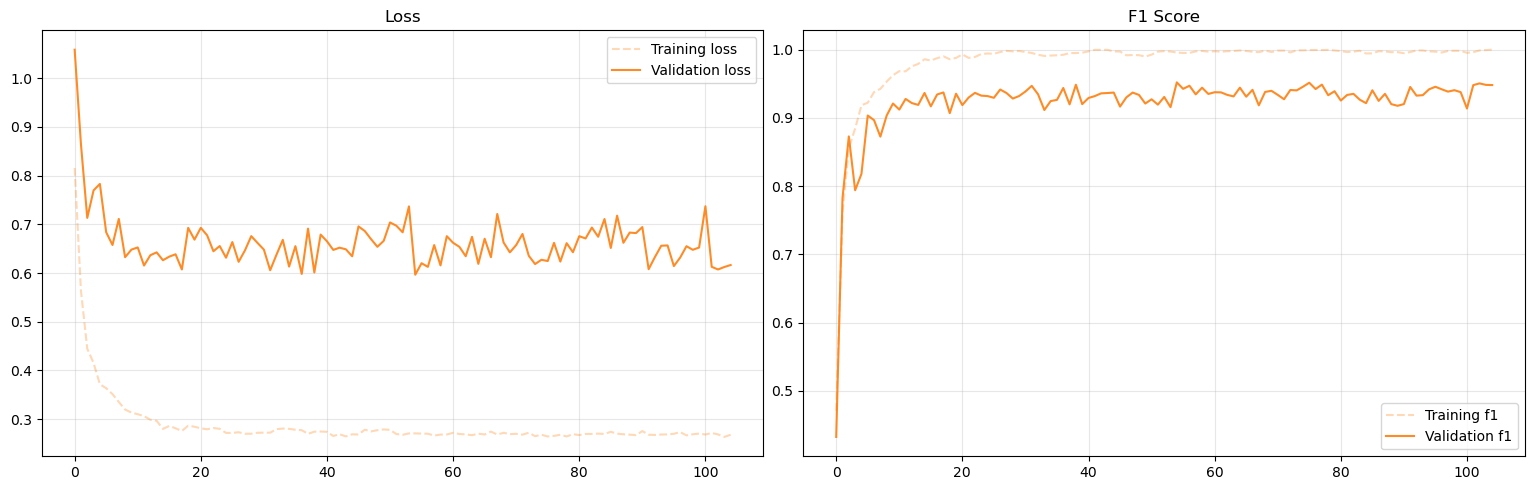

In [14]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first figure
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second figure
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Validation Accuracy: 0.9519
Precision: 0.9527
Recall: 0.9519
F1 Score: 0.9521

Detailed Classification Report:
              precision    recall  f1-score   support

     no_pain     0.9702    0.9744    0.9723       468
    low_pain     0.9605    0.9012    0.9299        81
   high_pain     0.7895    0.8333    0.8108        54

    accuracy                         0.9519       603
   macro avg     0.9067    0.9030    0.9043       603
weighted avg     0.9527    0.9519    0.9521       603



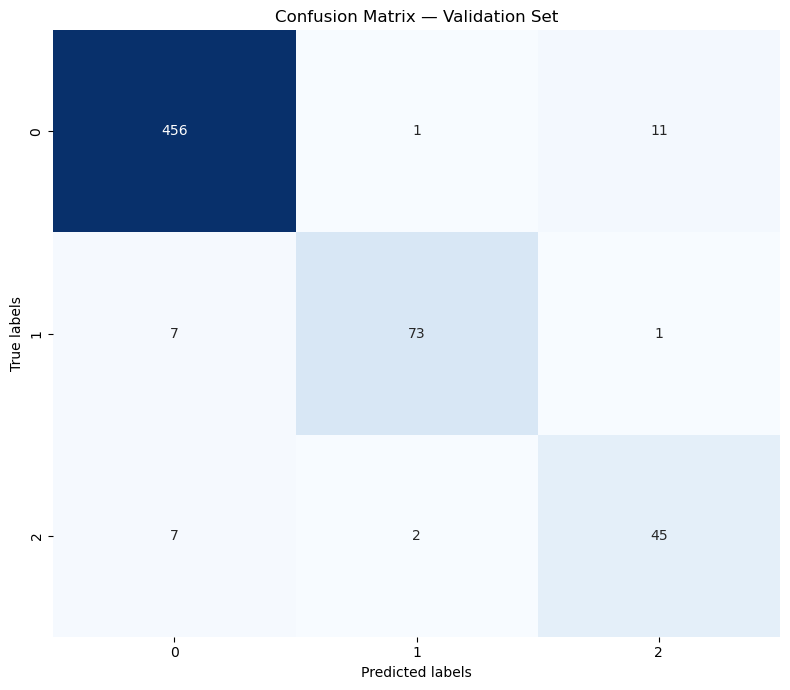

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

val_preds, val_targets = [], []
transformer_model.eval()

with torch.no_grad():
    for inputs, yb in val_loader:

        if len(inputs) == 4:
            cont, survey, body, time = inputs
        else:
            cont, survey, body = inputs
            time = None

        cont   = cont.to(device)
        survey = survey.to(device)
        body   = body.to(device)
        if time is not None:
            time = time.to(device)

        if transformer_model.use_time and time is not None:
            logits = transformer_model(cont, survey, body, time)
        else:
            logits = transformer_model(cont, survey, body)

        preds = logits.argmax(dim=1).cpu().numpy()
        val_preds.append(preds)
        val_targets.append(yb.numpy())

val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Precision: {val_prec:.4f}")
print(f"Recall: {val_rec:.4f}")
print(f"F1 Score: {val_f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(
    val_targets, val_preds,
    target_names=['no_pain', 'low_pain', 'high_pain'],
    digits=4
))

cm = confusion_matrix(val_targets, val_preds)
cm_labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=cm_labels, fmt='', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

In [16]:
from collections import Counter
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

NUM_TEST_SAMPLES = 1324
BATCH_SIZE = 64  

cont_test_tensor   = X_test_seq["cont"].float()
survey_test_tensor = X_test_seq["survey"].long()
body_test_tensor   = X_test_seq["body"].long()

if transformer_model.use_time:
    time_test_tensor = X_test_seq["time"].long()
    test_ds = TensorDataset(cont_test_tensor, survey_test_tensor, body_test_tensor, time_test_tensor)
else:
    test_ds = TensorDataset(cont_test_tensor, survey_test_tensor, body_test_tensor)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

transformer_model.eval()
test_preds = []

with torch.no_grad():

    if transformer_model.use_time:
        for cont, survey, body, time in tqdm(test_loader, desc="Running inference"):
            cont = cont.to(device)
            survey = survey.to(device)
            body = body.to(device)
            time = time.to(device)

            logits = transformer_model(cont, survey, body, time)
            preds = logits.argmax(dim=1).cpu().numpy()
            test_preds.append(preds)

    else:
        for cont, survey, body in tqdm(test_loader, desc="Running inference"):
            cont = cont.to(device)
            survey = survey.to(device)
            body = body.to(device)

            logits = transformer_model(cont, survey, body)
            preds = logits.argmax(dim=1).cpu().numpy()
            test_preds.append(preds)

test_preds = np.concatenate(test_preds)
print("Raw window-level predictions:", test_preds.shape)

windows_per_sample = len(test_preds) // NUM_TEST_SAMPLES
assert len(test_preds) % NUM_TEST_SAMPLES == 0, "Window count mismatch!"

agg_preds = []
for i in range(NUM_TEST_SAMPLES):
    start = i * windows_per_sample
    end   = (i + 1) * windows_per_sample
    chunk = test_preds[start:end]
    pred = Counter(chunk).most_common(1)[0][0]
    agg_preds.append(pred)

agg_preds = np.array(agg_preds)
print("Aggregated sample-level predictions:", agg_preds.shape)

label_map = {0: "no_pain", 1: "low_pain", 2: "high_pain"}
labels = [label_map[p] for p in agg_preds]

sample_indices = [f"{i:03d}" for i in range(NUM_TEST_SAMPLES)]

submission = pd.DataFrame({
    "sample_index": sample_indices,
    "label": labels
})

submission.to_csv("submission.csv", index=False)

print("Submission saved as submission.csv")
print("Rows:", len(submission))


Running inference: 100%|██████████| 187/187 [00:06<00:00, 27.43it/s]

Raw window-level predictions: (11916,)
Aggregated sample-level predictions: (1324,)
Submission saved as submission.csv
Rows: 1324
